# Clustering de Perfiles


In [1]:
# Cargamos librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score)

In [2]:
# Vamos a cargar el Dataset Maestro y el Dataset C

df_A= pd.read_csv(r"C:\Users\orlan\Documents\Aprendizaje Automatico\TP\dataset_A_casos_completos.csv", 
                 encoding= "ISO-8859-1")
df_C= pd.read_csv(r"C:\Users\orlan\Documents\Aprendizaje Automatico\TP\dataset_C_knn.csv", 
                 encoding= "ISO-8859-1")
print("Dimensiones Dataset A:")
print(df_A.shape)
print("Dimensiones Dataset C:")
print(df_C.shape)


Dimensiones Dataset A:
(8541, 653)
Dimensiones Dataset C:
(11041, 653)


In [3]:
# Vamos a separar las variables

meta_cols = ["archivo", "fecha", "time"]

X_meta = df_A[meta_cols]

X_temp_C = df_C.drop(columns=meta_cols)
X_temp_A = df_A.drop(columns=meta_cols)

alturas_km = X_temp_C.columns.astype(float) / 1000

print("\nTemperaturas Dataset A:")
print(X_temp_A.shape)

print("\nTemperaturas Dataset C:")
print(X_temp_C.shape)

print(
    f"\nRango vertical: "
    f"{alturas_km.min():.1f} - {alturas_km.max():.1f} km")

print(
    f"Cantidad de niveles atmosféricos: "
    f"{len(alturas_km)}")


Temperaturas Dataset A:
(8541, 650)

Temperaturas Dataset C:
(11041, 650)

Rango vertical: 15.1 - 80.0 km
Cantidad de niveles atmosféricos: 650


In [7]:
# Vamos a crear X la variabilidad térmica por altura
std_por_altura = X_temp_C.std(axis=0)

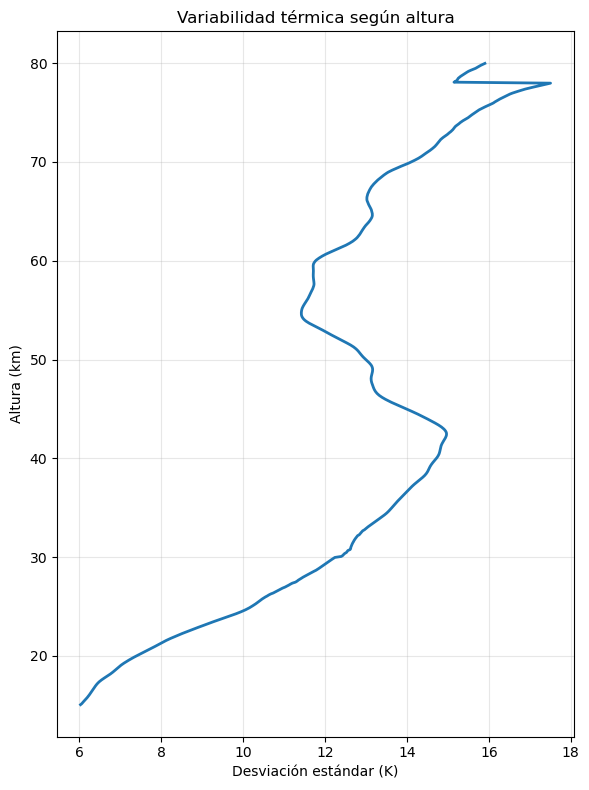

In [9]:
plt.figure(figsize=(6,8))

plt.plot(
    std_por_altura,
    alturas_km,
    linewidth=2
)

plt.xlabel("Desviación estándar (K)")
plt.ylabel("Altura (km)")
plt.title("Variabilidad térmica según altura")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [10]:
print(f"σ mínima: {std_por_altura.min():.2f} K")
print(f"σ máxima: {std_por_altura.max():.2f} K")
print(f"Relación max/min: {std_por_altura.max()/std_por_altura.min():.2f}")

σ mínima: 6.03 K
σ máxima: 17.51 K
Relación max/min: 2.90


In [11]:
# Vamos a buscar y gráficar los valores de k

k_values = range(2, 11)

resultados = []

for k in k_values:

    print(f"Procesando k = {k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = kmeans.fit_predict(X_temp_C)

    inertia = kmeans.inertia_

    # Silhouette sobre muestra para acelerar
    silhouette = silhouette_score(
        X_temp_C,
        labels,
        sample_size=3000,
        random_state=42
    )

    calinski = calinski_harabasz_score(
        X_temp_C,
        labels
    )

    davies = davies_bouldin_score(
        X_temp_C,
        labels
    )

    resultados.append([
        k,
        inertia,
        silhouette,
        calinski,
        davies
    ])

# ------------------------------------------------------------
# DataFrame resumen
# ------------------------------------------------------------

metricas_clusters = pd.DataFrame(
    resultados,
    columns=[
        "k",
        "inercia",
        "silhouette",
        "calinski_harabasz",
        "davies_bouldin"
    ]
)

metricas_clusters

Procesando k = 2...
Procesando k = 3...
Procesando k = 4...
Procesando k = 5...
Procesando k = 6...
Procesando k = 7...
Procesando k = 8...
Procesando k = 9...
Procesando k = 10...


,k,inercia,silhouette,calinski_harabasz,davies_bouldin
0,2,7.319182e+08,0.333028,6551.838706,1.186397
1,3,6.299636e+08,0.248642,4698.963158,1.623498
2,4,5.750318e+08,0.240730,3783.036019,1.730355
3,5,5.414881e+08,0.176735,3183.677770,1.732773
4,6,5.117639e+08,0.182450,2822.815606,1.720300
5,7,4.821014e+08,0.183315,2610.003479,1.499916
6,8,4.606647e+08,0.172332,2414.381956,1.550683
7,9,4.469151e+08,0.173474,2219.807860,1.681158
8,10,4.333092e+08,0.162704,2073.420843,1.785713


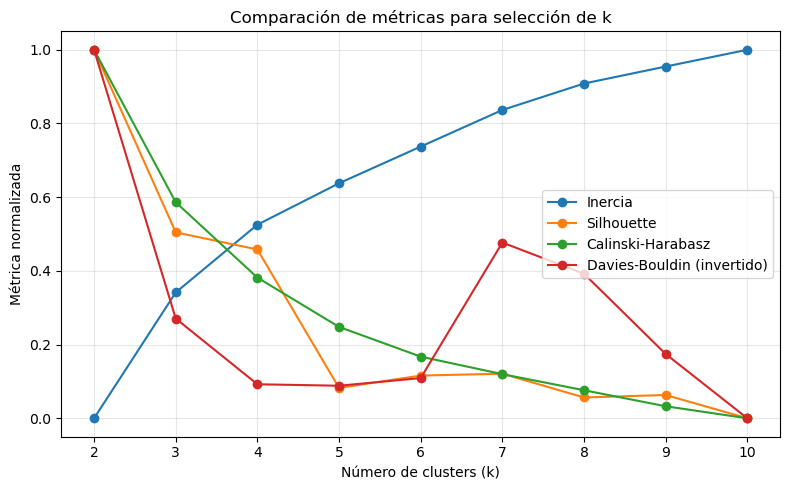

In [12]:
# Vamos a graficarlos todos juntos

# ============================================================
# Comparación conjunta de métricas
# ============================================================

metricas_plot = metricas_clusters.copy()

# Normalización Min-Max
for col in [
    "inercia",
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin"
]:
    metricas_plot[col] = (
        metricas_plot[col] - metricas_plot[col].min()
    ) / (
        metricas_plot[col].max() - metricas_plot[col].min()
    )

# Davies-Bouldin: menor es mejor
metricas_plot["davies_bouldin"] = 1 - metricas_plot["davies_bouldin"]

# Inercia: menor es mejor
metricas_plot["inercia"] = 1 - metricas_plot["inercia"]

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    metricas_plot["k"],
    metricas_plot["inercia"],
    marker="o",
    label="Inercia"
)

plt.plot(
    metricas_plot["k"],
    metricas_plot["silhouette"],
    marker="o",
    label="Silhouette"
)

plt.plot(
    metricas_plot["k"],
    metricas_plot["calinski_harabasz"],
    marker="o",
    label="Calinski-Harabasz"
)

plt.plot(
    metricas_plot["k"],
    metricas_plot["davies_bouldin"],
    marker="o",
    label="Davies-Bouldin (invertido)"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Métrica normalizada")
plt.title("Comparación de métricas para selección de k")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [13]:
metricas_clusters.round(3)

,k,inercia,silhouette,calinski_harabasz,davies_bouldin
0,2,7.319182e+08,0.333,6551.839,1.186
1,3,6.299636e+08,0.249,4698.963,1.623
2,4,5.750318e+08,0.241,3783.036,1.730
3,5,5.414881e+08,0.177,3183.678,1.733
4,6,5.117639e+08,0.182,2822.816,1.720
5,7,4.821014e+08,0.183,2610.003,1.500
6,8,4.606647e+08,0.172,2414.382,1.551
7,9,4.469151e+08,0.173,2219.808,1.681
8,10,4.333092e+08,0.163,2073.421,1.786


### Vamos a analizar

Selección preliminar del número de clusters
1. Criterio del codo (Inercia)

La curva de inercia presenta un cambio de pendiente marcado en torno a k = 4. Hasta ese valor, el aumento en el número de clusters produce una reducción importante de la variabilidad interna de los grupos. A partir de allí, la mejora es progresivamente menor, lo que indica que agregar más clusters aporta un beneficio limitado en términos de homogeneidad.

2. Silhouette, combinado con Calinski-Harabasz

Las métricas de Silhouette y Calinski-Harabasz muestran sus valores más altos para números bajos de clusters y disminuyen de forma sostenida al aumentar k. En particular, se observa una caída importante a partir de k = 5, lo que sugiere que los nuevos grupos comienzan a ser menos compactos y menos separados entre sí. Si seguimos aumentando la cantidad de clusters, probablemente nos lleve a una fragmentación innecesaria de la estructura de los datos.

3. Davies-Bouldin

El índice Davies-Bouldin presenta una mejora local para valores más altos de k, en particular en k = 7. Sin embargo, esta tendencia no es acompañada por las demás métricas.

Conclusión

Considerando simultáneamente la inercia, el índice de Silhouette, Calinski-Harabasz y Davies-Bouldin, k = 4 surge como el mejor compromiso entre simplicidad del modelo, cohesión interna de los clusters y separación entre grupos.

No obstante, dado que el especialista del dominio espera la existencia de aproximadamente 4 a 6 estados atmosféricos característicos, también se analizará el caso k = 5 para evaluar si aporta una diferenciación físicamente interpretable respecto de la solución de cuatro clusters.

In [14]:
# Vamos a ver comenzar con K=4

kmeans_4 = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42,
    n_init=50
)

labels_4 = kmeans_4.fit_predict(X_temp_C)

df_C["cluster_4"] = labels_4

In [15]:
# Vamos a ver el tamaño de los clusters

cluster_sizes_4 = (
    pd.Series(labels_4)
    .value_counts()
    .sort_index()
)

cluster_sizes_pct_4 = (
    100 * cluster_sizes_4 / len(labels_4)
)

resumen_clusters_4 = pd.DataFrame({
    "Perfiles": cluster_sizes_4,
    "Porcentaje": cluster_sizes_pct_4
})

display(resumen_clusters_4.round(2))


,Perfiles,Porcentaje
0,1752,15.87
1,2741,24.83
2,3776,34.20
3,2772,25.11


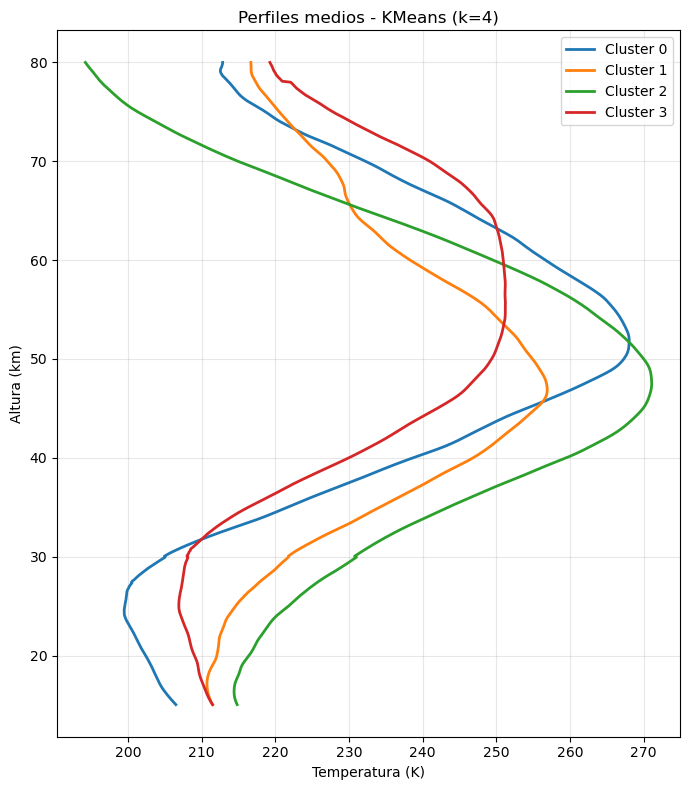

In [16]:
# Vamos a graficar los perfiles de los 4 clusters

plt.figure(figsize=(7,8))

for cluster in sorted(np.unique(labels_4)):

    perfil_medio = (
        X_temp_C[labels_4 == cluster]
        .mean()
    )

    plt.plot(
        perfil_medio,
        alturas_km,
        linewidth=2,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Temperatura (K)")
plt.ylabel("Altura (km)")
plt.title("Perfiles medios - KMeans (k=4)")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

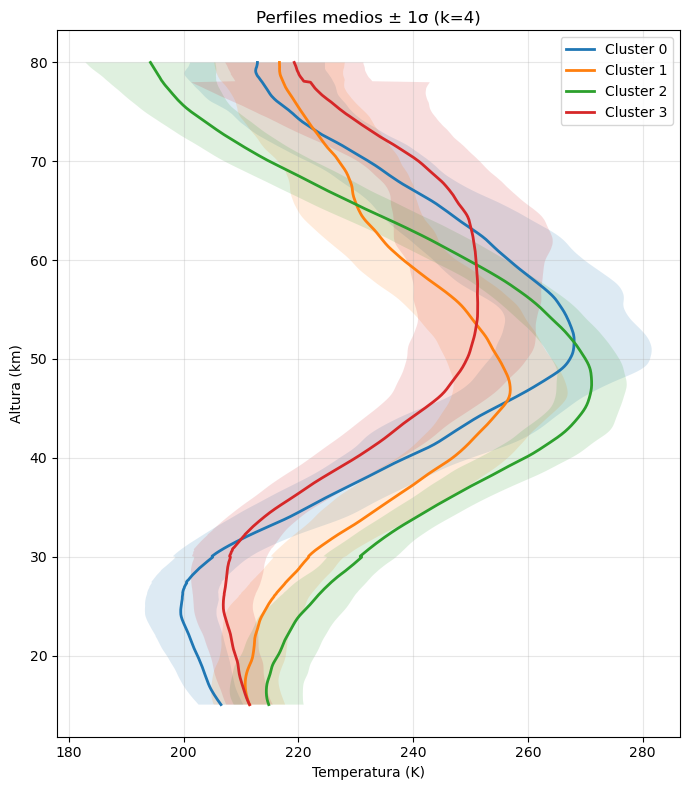

In [17]:
# Vamos a ver qué tan compactos son

plt.figure(figsize=(7,8))

for cluster in sorted(np.unique(labels_4)):

    datos_cluster = X_temp_C[labels_4 == cluster]

    perfil_medio = datos_cluster.mean()
    perfil_std = datos_cluster.std()

    plt.plot(
        perfil_medio,
        alturas_km,
        linewidth=2,
        label=f"Cluster {cluster}"
    )

    plt.fill_betweenx(
        alturas_km,
        perfil_medio - perfil_std,
        perfil_medio + perfil_std,
        alpha=0.15
    )

plt.xlabel("Temperatura (K)")
plt.ylabel("Altura (km)")
plt.title("Perfiles medios ± 1σ (k=4)")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Conclusiones parciales

Cada cluster representa estados bien diferenciados. La elección de K=4 por ahora es acertada.

### Paso siguiente

Vamos a ver si K=5 nos brinda una forma nueva.

,Perfiles,Porcentaje
0,2739,24.81
1,2646,23.97
2,1678,15.20
3,2507,22.71
4,1471,13.32


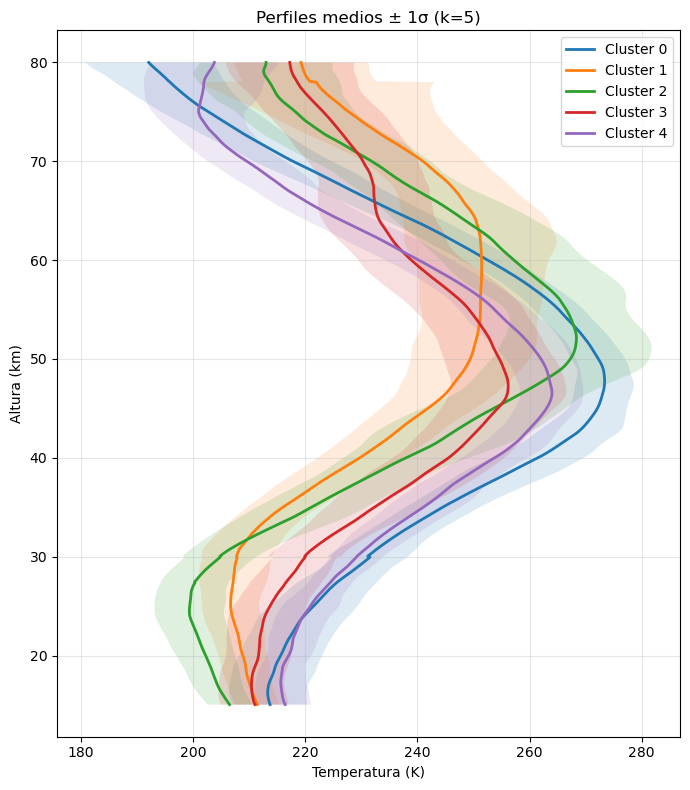

In [18]:
# Vamos a ver comenzar con K=5

kmeans_5 = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=50
)

labels_5 = kmeans_5.fit_predict(X_temp_C)

df_C["cluster_5"] = labels_5

# Vamos a ver el tamaño de los clusters

cluster_sizes_5 = (
    pd.Series(labels_5)
    .value_counts()
    .sort_index()
)

cluster_sizes_pct_5 = (
    100 * cluster_sizes_5 / len(labels_5)
)

resumen_clusters_5 = pd.DataFrame({
    "Perfiles": cluster_sizes_5,
    "Porcentaje": cluster_sizes_pct_5
})

display(resumen_clusters_5.round(2))

# Vamos a ver qué tan compactos son

plt.figure(figsize=(7,8))

for cluster in sorted(np.unique(labels_5)):

    datos_cluster = X_temp_C[labels_5 == cluster]

    perfil_medio = datos_cluster.mean()
    perfil_std = datos_cluster.std()

    plt.plot(
        perfil_medio,
        alturas_km,
        linewidth=2,
        label=f"Cluster {cluster}"
    )

    plt.fill_betweenx(
        alturas_km,
        perfil_medio - perfil_std,
        perfil_medio + perfil_std,
        alpha=0.15
    )

plt.xlabel("Temperatura (K)")
plt.ylabel("Altura (km)")
plt.title("Perfiles medios ± 1σ (k=5)")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
# Vamos a ver la distancia entre centroides

from scipy.spatial.distance import cdist

distancias = pd.DataFrame(
    cdist(
        kmeans_4.cluster_centers_,
        kmeans_5.cluster_centers_
    ),
    index=[f"K4_C{i}" for i in range(4)],
    columns=[f"K5_C{i}" for i in range(5)]
)

distancias.round(2)

,K5_C0,K5_C1,K5_C2,K5_C3,K5_C4
K4_C0,418.22,240.15,10.66,286.81,434.13
K4_C1,332.26,306.03,313.30,40.52,242.98
K4_C2,52.03,536.08,424.79,335.85,152.95
K4_C3,541.88,7.17,241.18,265.66,503.38


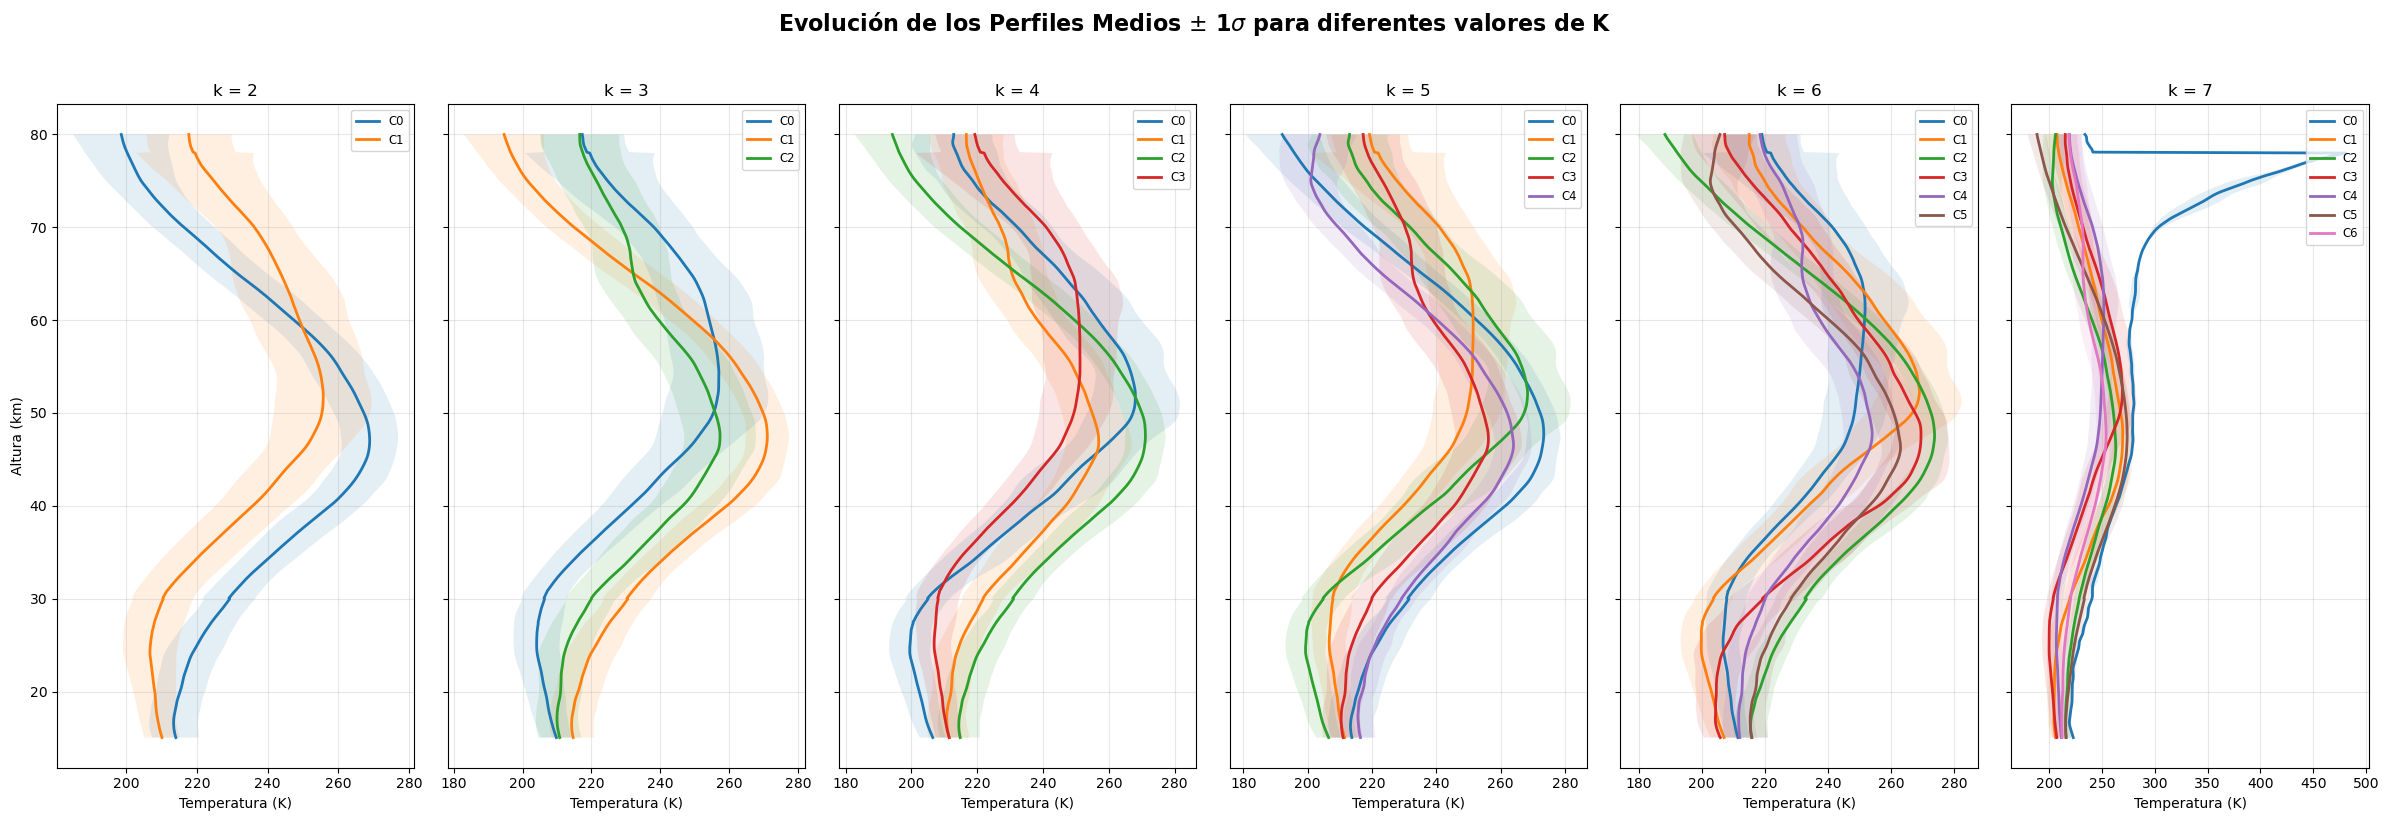

In [20]:
# vamos a graficar K=2 a K=7

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# 1. Configuración de la figura: 1 fila con 6 gráficos uno al lado del otro
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(24, 8), sharey=True)

# Lista de los K que queremos evaluar (de 2 a 7)
valores_k = range(2, 8)

# 2. Bucle para calcular, almacenar y graficar cada K
for i, k in enumerate(valores_k):
    # Seleccionamos el eje (subgráfico) actual
    ax = axes[i]
    
    # Instanciamos y entrenamos el modelo con los mismos parámetros
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=50
    )
    labels = kmeans.fit_predict(X_temp_C)
    
    # Guardamos las etiquetas en el DataFrame original dinámicamente (ej: cluster_2, cluster_3...)
    df_C[f"cluster_{k}"] = labels
    
    # --- Bloque de Gráfico ---
    # Iteramos sobre cada cluster de este K para dibujarlo en su respectivo subgráfico
    for cluster in sorted(np.unique(labels)):
        datos_cluster = X_temp_C[labels == cluster]
        
        perfil_medio = datos_cluster.mean()
        perfil_std = datos_cluster.std()
        
        # Graficamos la línea del centroide en el eje 'ax'
        ax.plot(
            perfil_medio,
            alturas_km,
            linewidth=2,
            label=f"C{cluster}"
        )
        
        # Graficamos el sombreado de la desviación estándar en el eje 'ax'
        ax.fill_betweenx(
            alturas_km,
            perfil_medio - perfil_std,
            perfil_medio + perfil_std,
            alpha=0.12
        )
    
    # Configuración cosmética de cada subgráfico individual
    ax.set_xlabel("Temperatura (K)")
    ax.set_title(f"k = {k}")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize="small")
    
    # Solo le ponemos la etiqueta del eje Y al primer gráfico (ya que comparten el eje Y)
    if i == 0:
        ax.set_ylabel("Altura (km)")

# Ajuste general de la figura para que no se superpongan las etiquetas
plt.suptitle("Evolución de los Perfiles Medios $\pm$ 1$\sigma$ para diferentes valores de K", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# A ver si están vinculados a las estaciones

# ------------------------------------------------------------
# Fecha
# ------------------------------------------------------------

df_C["fecha"] = pd.to_datetime(df_C["fecha"])

# ------------------------------------------------------------
# Mes
# ------------------------------------------------------------

df_C["mes"] = df_C["fecha"].dt.month

# ------------------------------------------------------------
# Estaciones (Hemisferio Sur)
# ------------------------------------------------------------

def obtener_estacion(mes):

    if mes in [12, 1, 2]:
        return "Verano"

    elif mes in [3, 4, 5]:
        return "Otoño"

    elif mes in [6, 7, 8]:
        return "Invierno"

    else:
        return "Primavera"

df_C["estacion"] = df_C["mes"].apply(obtener_estacion)

#Tabla de contingencia

tabla_estaciones = pd.crosstab(
    df_C["estacion"],
    df_C["cluster_4"]
)

tabla_estaciones




cluster_4,0,1,2,3
estacion,,,,
Invierno,1320,648,195,1309
Otoño,163,1180,731,1397
Primavera,269,912,1239,54
Verano,0,1,1611,12


In [22]:
tabla_pct = pd.crosstab(
    df_C["estacion"],
    df_C["cluster_4"],
    normalize="index"
) * 100

tabla_pct.round(1)

cluster_4,0,1,2,3
estacion,,,,
Invierno,38.0,18.7,5.6,37.7
Otoño,4.7,34.0,21.1,40.2
Primavera,10.9,36.9,50.1,2.2
Verano,0.0,0.1,99.2,0.7


In [23]:
# vamos a ver cómo se distribuyen los clusters a lo largo de los meses del año

df_C["mes"] = df_C["fecha"].dt.month

tabla_mensual = pd.crosstab(
    df_C["mes"],
    df_C["cluster_4"],
    normalize="index"
) * 100

tabla_mensual = tabla_mensual.round(1)

meses = [
    "Ene", "Feb", "Mar", "Abr",
    "May", "Jun", "Jul", "Ago",
    "Sep", "Oct", "Nov", "Dic"
]

tabla_mensual.index = meses

tabla_mensual

cluster_4,0,1,2,3
Ene,0.0,0.2,98.0,1.9
Feb,0.0,0.0,100.0,0.0
Mar,0.0,30.2,69.8,0.0
Abr,0.0,69.2,0.5,30.3
May,13.7,0.8,0.0,85.5
Jun,42.4,0.5,0.0,57.1
Jul,39.9,23.6,13.2,23.3
Ago,26.0,41.7,0.0,32.3
Sep,23.3,65.8,5.9,5.0
Oct,2.3,25.4,72.3,0.0


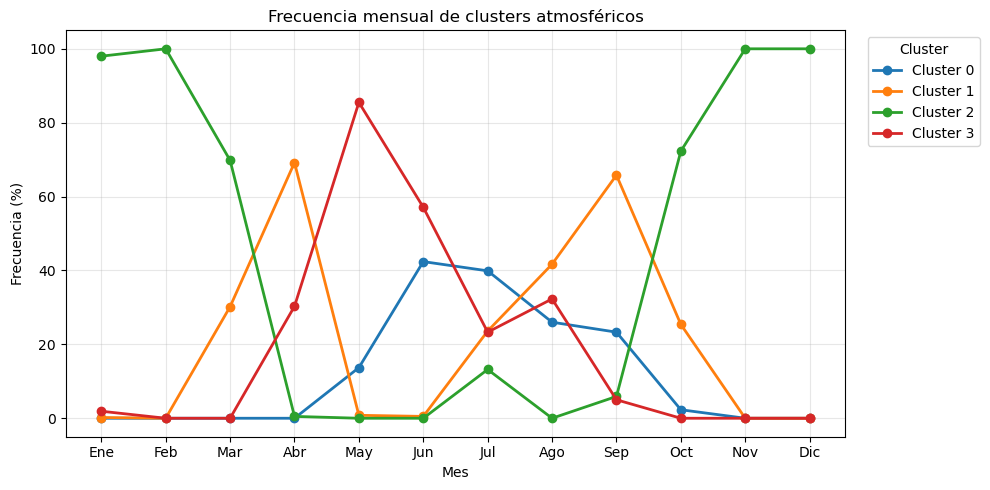

In [24]:
plt.figure(figsize=(10,5))

for cluster in tabla_mensual.columns:

    plt.plot(
        tabla_mensual.index,
        tabla_mensual[cluster],
        marker="o",
        linewidth=2,
        label=f"Cluster {cluster}"
    )

plt.ylabel("Frecuencia (%)")
plt.xlabel("Mes")
plt.title("Frecuencia mensual de clusters atmosféricos")

plt.grid(alpha=0.3)

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

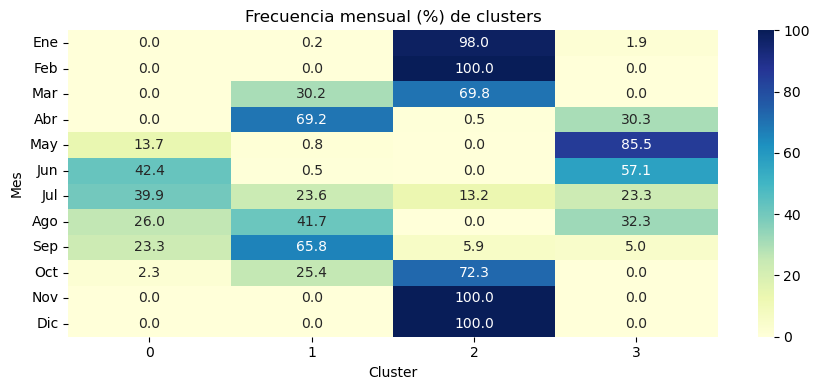

In [25]:
import seaborn as sns

plt.figure(figsize=(9,4))

sns.heatmap(
    tabla_mensual,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Frecuencia mensual (%) de clusters")

plt.xlabel("Cluster")
plt.ylabel("Mes")

plt.tight_layout()
plt.show()

### Conclusiones

La distribución mensual de los clusters mostró una dependencia estacional muy marcada. El Cluster 2 domina casi exclusivamente durante los meses cálidos, mientras que los Clusters 0 y 3 predominan principalmente en invierno. Por otro lado, el Cluster 1 aparece con mayor frecuencia durante las estaciones de transición.

La evolución mensual presenta cambios graduales y coherentes a lo largo del año, lo que sugiere que los clusters obtenidos representan estados atmosféricos físicamente consistentes y asociados al ciclo estacional de la atmósfera media.


### Con esto vimos los estados que existen
### Ahora veamos cómo evoluciona la noche

In [26]:
# ============================================================
# Distribución de clusters por noche
# ============================================================

distribucion_nocturna = pd.crosstab(
    df_C["fecha"],
    df_C["cluster_4"],
    normalize="index"
)

distribucion_nocturna.columns = [
    f"C{c}" for c in distribucion_nocturna.columns
]

distribucion_nocturna.head()

,C0,C1,C2,C3
fecha,,,,
2022-01-02,0.0,0.0,1.0,0.0
2022-01-03,0.0,0.0,1.0,0.0
2022-01-04,0.0,0.0,1.0,0.0
2022-01-06,0.0,0.0,1.0,0.0
2022-01-08,0.0,0.0,1.0,0.0


In [27]:
# ------------------------------------------------------------
# Cluster dominante
# ------------------------------------------------------------

distribucion_nocturna["cluster_dominante"] = (
    distribucion_nocturna.idxmax(axis=1)
)

distribucion_nocturna["max_pct"] = (
    distribucion_nocturna[
        [c for c in distribucion_nocturna.columns if c.startswith("C")]
    ].max(axis=1)
)

distribucion_nocturna.head()

,C0,C1,C2,C3,cluster_dominante,max_pct
fecha,,,,,,
2022-01-02,0.0,0.0,1.0,0.0,C2,1.0
2022-01-03,0.0,0.0,1.0,0.0,C2,1.0
2022-01-04,0.0,0.0,1.0,0.0,C2,1.0
2022-01-06,0.0,0.0,1.0,0.0,C2,1.0
2022-01-08,0.0,0.0,1.0,0.0,C2,1.0


In [28]:
distribucion_nocturna.sort_values(
    "max_pct",
    ascending=False
).head(10)

,C0,C1,C2,C3,cluster_dominante,max_pct
fecha,,,,,,
2022-01-02,0.0,0.0,1.0,0.0,C2,1.0
2023-12-19,0.0,0.0,1.0,0.0,C2,1.0
2024-01-15,0.0,0.0,1.0,0.0,C2,1.0
2024-01-12,0.0,0.0,1.0,0.0,C2,1.0
2024-01-11,0.0,0.0,1.0,0.0,C2,1.0
2024-01-10,0.0,0.0,1.0,0.0,C2,1.0
2024-01-09,0.0,0.0,1.0,0.0,C2,1.0
2024-01-06,0.0,0.0,1.0,0.0,C2,1.0
2024-01-04,0.0,0.0,1.0,0.0,C2,1.0


In [29]:
distribucion_nocturna.sort_values(
    "max_pct",
    ascending=True
).head(10)

,C0,C1,C2,C3,cluster_dominante,max_pct
fecha,,,,,,
2023-06-21,0.285714,0.285714,0.000000,0.428571,C3,0.428571
2023-07-04,0.483333,0.483333,0.000000,0.033333,C0,0.483333
2023-07-10,0.500000,0.392857,0.000000,0.107143,C0,0.500000
2022-07-02,0.500000,0.500000,0.000000,0.000000,C0,0.500000
2024-08-07,0.000000,0.500000,0.000000,0.500000,C1,0.500000
2024-07-30,0.500000,0.500000,0.000000,0.000000,C0,0.500000
2024-06-05,0.500000,0.000000,0.000000,0.500000,C0,0.500000
2023-05-24,0.487179,0.000000,0.000000,0.512821,C3,0.512821
2022-03-20,0.000000,0.513514,0.486486,0.000000,C1,0.513514


In [30]:
fecha_ejemplo = "2023-06-21"

noche = df_C[df_C["fecha"] == fecha_ejemplo].copy()

print(noche.shape)

(7, 661)


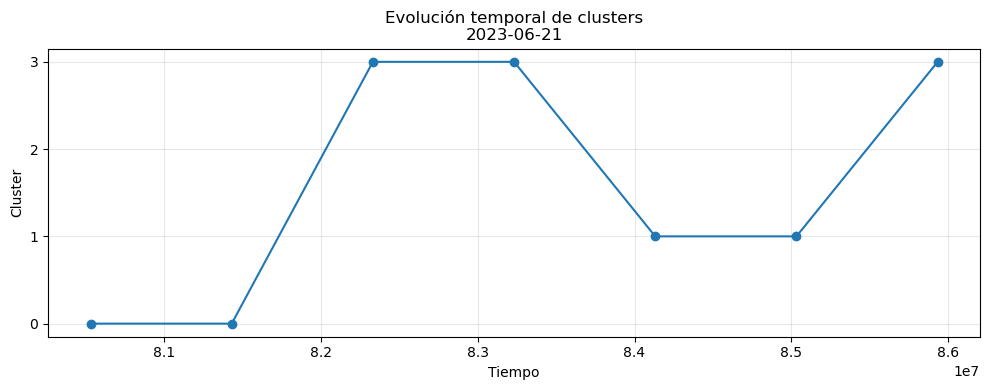

In [31]:
plt.figure(figsize=(10,4))

plt.plot(
    noche["time"],
    noche["cluster_4"],
    marker="o",
    linestyle="-"
)

plt.xlabel("Tiempo")
plt.ylabel("Cluster")
plt.title(f"Evolución temporal de clusters\n{fecha_ejemplo}")

plt.yticks([0,1,2,3])

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

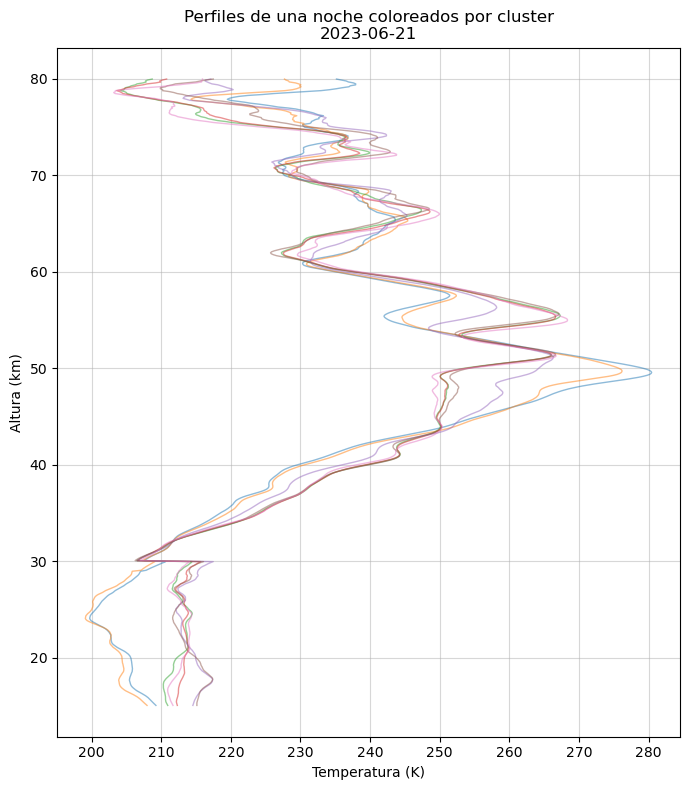

In [32]:
plt.figure(figsize=(7,8))

for cluster in sorted(noche["cluster_4"].unique()):

    datos_cluster = noche[
        noche["cluster_4"] == cluster
    ]

    for _, fila in datos_cluster.iterrows():

        perfil = fila[X_temp_C.columns]

        plt.plot(
            perfil,
            alturas_km,
            alpha=0.5,
            linewidth=1,
            label=f"Cluster {cluster}"
        )

plt.xlabel("Temperatura (K)")
plt.ylabel("Altura (km)")
plt.title(f"Perfiles de una noche coloreados por cluster\n{fecha_ejemplo}")

plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

In [33]:
from scipy.stats import entropy

# ============================================================
# Entropía nocturna
# ============================================================

cluster_cols = ["C0", "C1", "C2", "C3"]

distribucion_nocturna["entropia"] = (
    distribucion_nocturna[cluster_cols]
    .apply(lambda x: entropy(x + 1e-12), axis=1)
)

distribucion_nocturna.head()

,C0,C1,C2,C3,cluster_dominante,max_pct,entropia
fecha,,,,,,,
2022-01-02,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2022-01-03,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2022-01-04,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2022-01-06,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2022-01-08,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11


In [34]:
distribucion_nocturna.sort_values(
    "entropia"
).head(10)

,C0,C1,C2,C3,cluster_dominante,max_pct,entropia
fecha,,,,,,,
2022-01-02,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2023-11-29,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2023-11-27,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2023-11-26,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2023-11-24,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2023-11-23,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2023-11-15,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2023-11-14,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2023-11-10,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11


In [35]:
distribucion_nocturna.sort_values(
    "entropia",
    ascending=False
).head(10)

,C0,C1,C2,C3,cluster_dominante,max_pct,entropia
fecha,,,,,,,
2023-06-21,0.285714,0.285714,0.000000,0.428571,C3,0.428571,1.078992
2024-07-05,0.529412,0.235294,0.235294,0.000000,C0,0.529412,1.017603
2022-09-05,0.200000,0.550000,0.000000,0.250000,C1,0.550000,0.997272
2024-08-28,0.283333,0.550000,0.000000,0.166667,C1,0.550000,0.984757
2023-07-10,0.500000,0.392857,0.000000,0.107143,C0,0.500000,0.952937
2024-07-01,0.274194,0.112903,0.000000,0.612903,C3,0.612903,0.901098
2023-06-18,0.666667,0.148148,0.000000,0.185185,C0,0.666667,0.865501
2023-07-04,0.483333,0.483333,0.000000,0.033333,C0,0.483333,0.816187
2022-07-02,0.500000,0.500000,0.000000,0.000000,C0,0.500000,0.693147


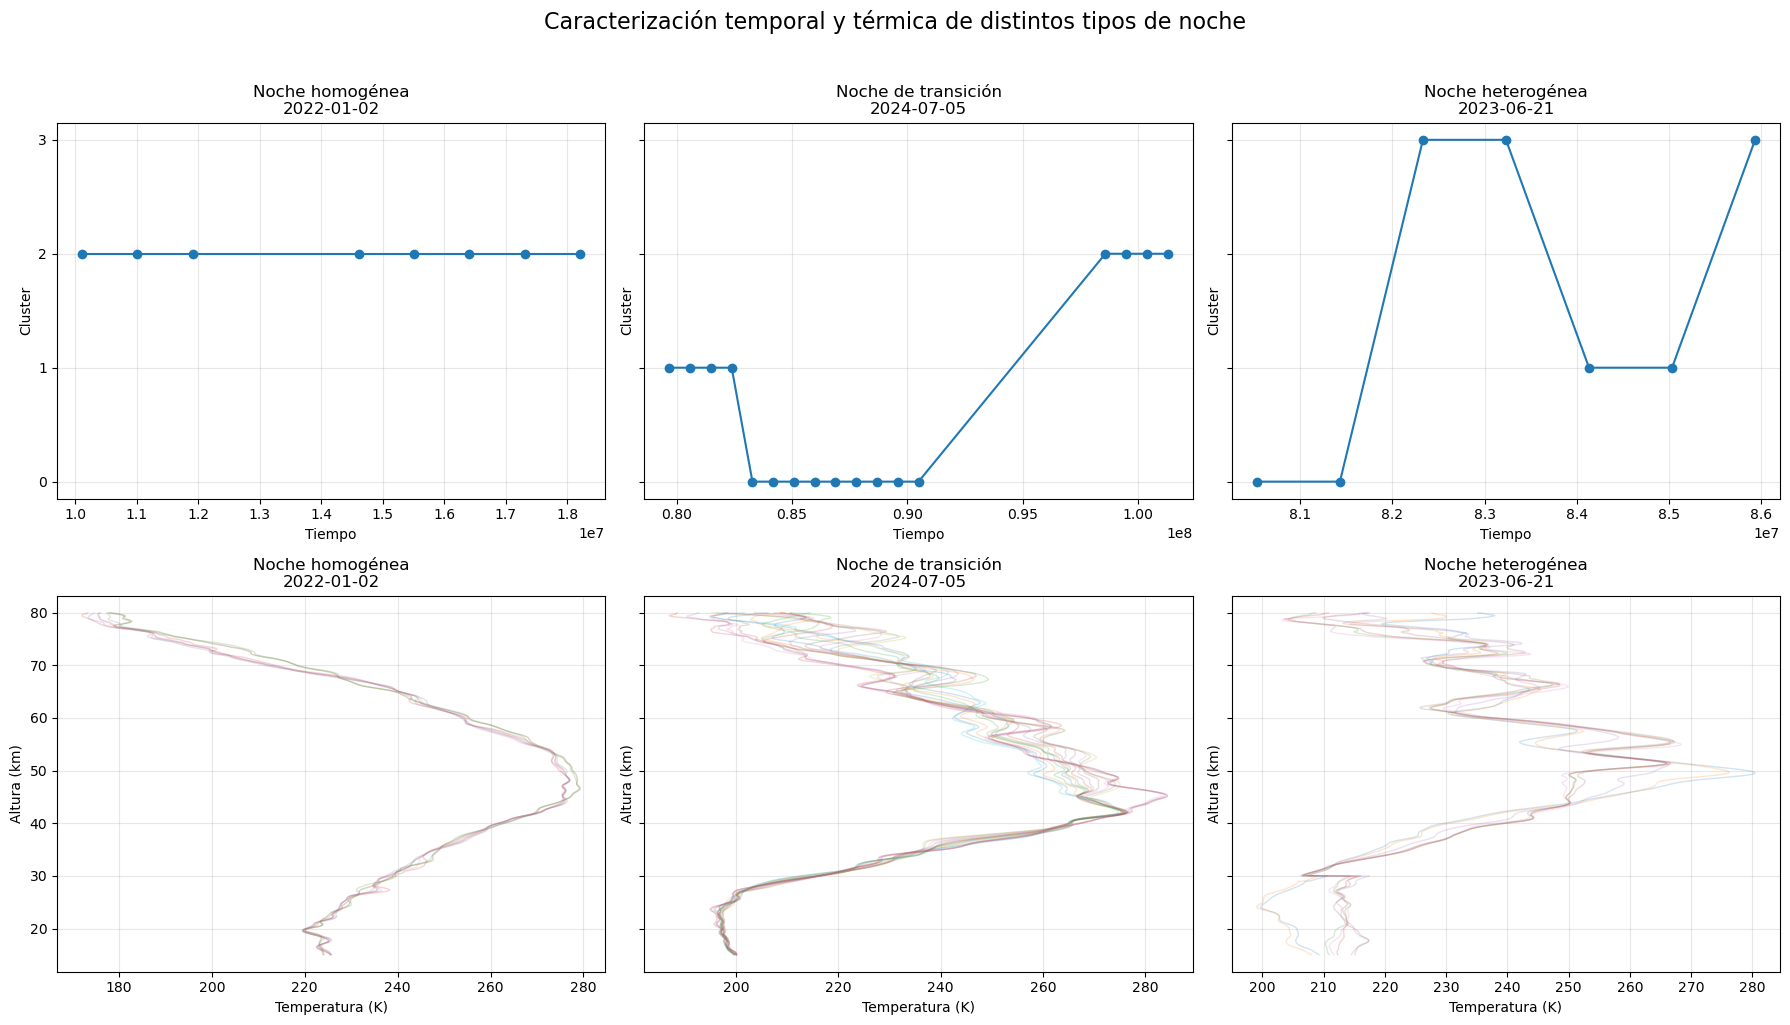

In [36]:
# ============================================================
# Comparación de tipos de noche
# Grilla 3x2
# ============================================================

# ------------------------------------------------------------
# Fechas de ejemplo
# ------------------------------------------------------------

fecha_homogenea = "2022-01-02"
fecha_transicion = "2024-07-05"
fecha_heterogenea = "2023-06-21"

fechas_ejemplo = {
    "Noche homogénea": fecha_homogenea,
    "Noche de transición": fecha_transicion,
    "Noche heterogénea": fecha_heterogenea
}

# ============================================================
# Figura general
# ============================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10),
    sharey='row'
)

# ============================================================
# Fila superior:
# Evolución temporal de clusters
# ============================================================

for i, (tipo_noche, fecha) in enumerate(fechas_ejemplo.items()):

    ax = axes[0, i]

    noche = df_C[df_C["fecha"] == fecha].copy()
    noche = noche.sort_values("time")

    ax.plot(
        noche["time"],
        noche["cluster_4"],
        marker="o",
        linestyle="-"
    )

    ax.set_title(f"{tipo_noche}\n{fecha}")

    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Cluster")

    ax.set_yticks([0, 1, 2, 3])

    ax.grid(alpha=0.3)

# ============================================================
# Fila inferior:
# Perfiles térmicos
# ============================================================

for i, (tipo_noche, fecha) in enumerate(fechas_ejemplo.items()):

    ax = axes[1, i]

    noche = df_C[df_C["fecha"] == fecha].copy()
    noche = noche.sort_values("time")

    for cluster in sorted(noche["cluster_4"].unique()):

        datos_cluster = noche[
            noche["cluster_4"] == cluster
        ]

        for _, fila in datos_cluster.iterrows():

            perfil = fila[X_temp_C.columns]

            ax.plot(
                perfil,
                alturas_km,
                alpha=0.20,
                linewidth=1
            )

    ax.set_title(f"{tipo_noche}\n{fecha}")

    ax.set_xlabel("Temperatura (K)")
    ax.set_ylabel("Altura (km)")

    ax.grid(alpha=0.3)

# ============================================================
# Ajustes finales
# ============================================================

plt.suptitle(
    "Caracterización temporal y térmica de distintos tipos de noche",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.show()

### Ultimas conclusiones

El análisis de clustering permitió identificar cuatro estados atmosféricos principales asociados a distintas configuraciones térmicas de la atmósfera media. Los clusters obtenidos presentan coherencia estadística, dependencia estacional y persistencia temporal dentro de las noches analizadas. Además, se observaron noches homogéneas, transiciones graduales entre estados y noches altamente variables, sugiriendo que la clasificación obtenida captura estructuras dinámicas físicamente relevantes.

In [37]:
# Voy a mostrar la noche más representativa de cada cluster

# ============================================================
# Noche más representativa de cada cluster
# ============================================================

fechas_clusters = {}

for cluster in ["C0", "C1", "C2", "C3"]:

    fecha = (
        distribucion_nocturna[cluster]
        .idxmax()
    )

    porcentaje = (
        distribucion_nocturna
        .loc[fecha, cluster]
    )

    fechas_clusters[cluster] = {
        "fecha": fecha,
        "porcentaje": porcentaje
    }

# ------------------------------------------------------------
# Mostrar resultados
# ------------------------------------------------------------

for cluster, info in fechas_clusters.items():

    print(
        f"{cluster}: "
        f"{info['fecha']} "
        f"({100*info['porcentaje']:.1f} %)")

C0: 2022-06-02 00:00:00 (100.0 %)
C1: 2022-03-28 00:00:00 (100.0 %)
C2: 2022-01-02 00:00:00 (100.0 %)
C3: 2022-01-24 00:00:00 (100.0 %)


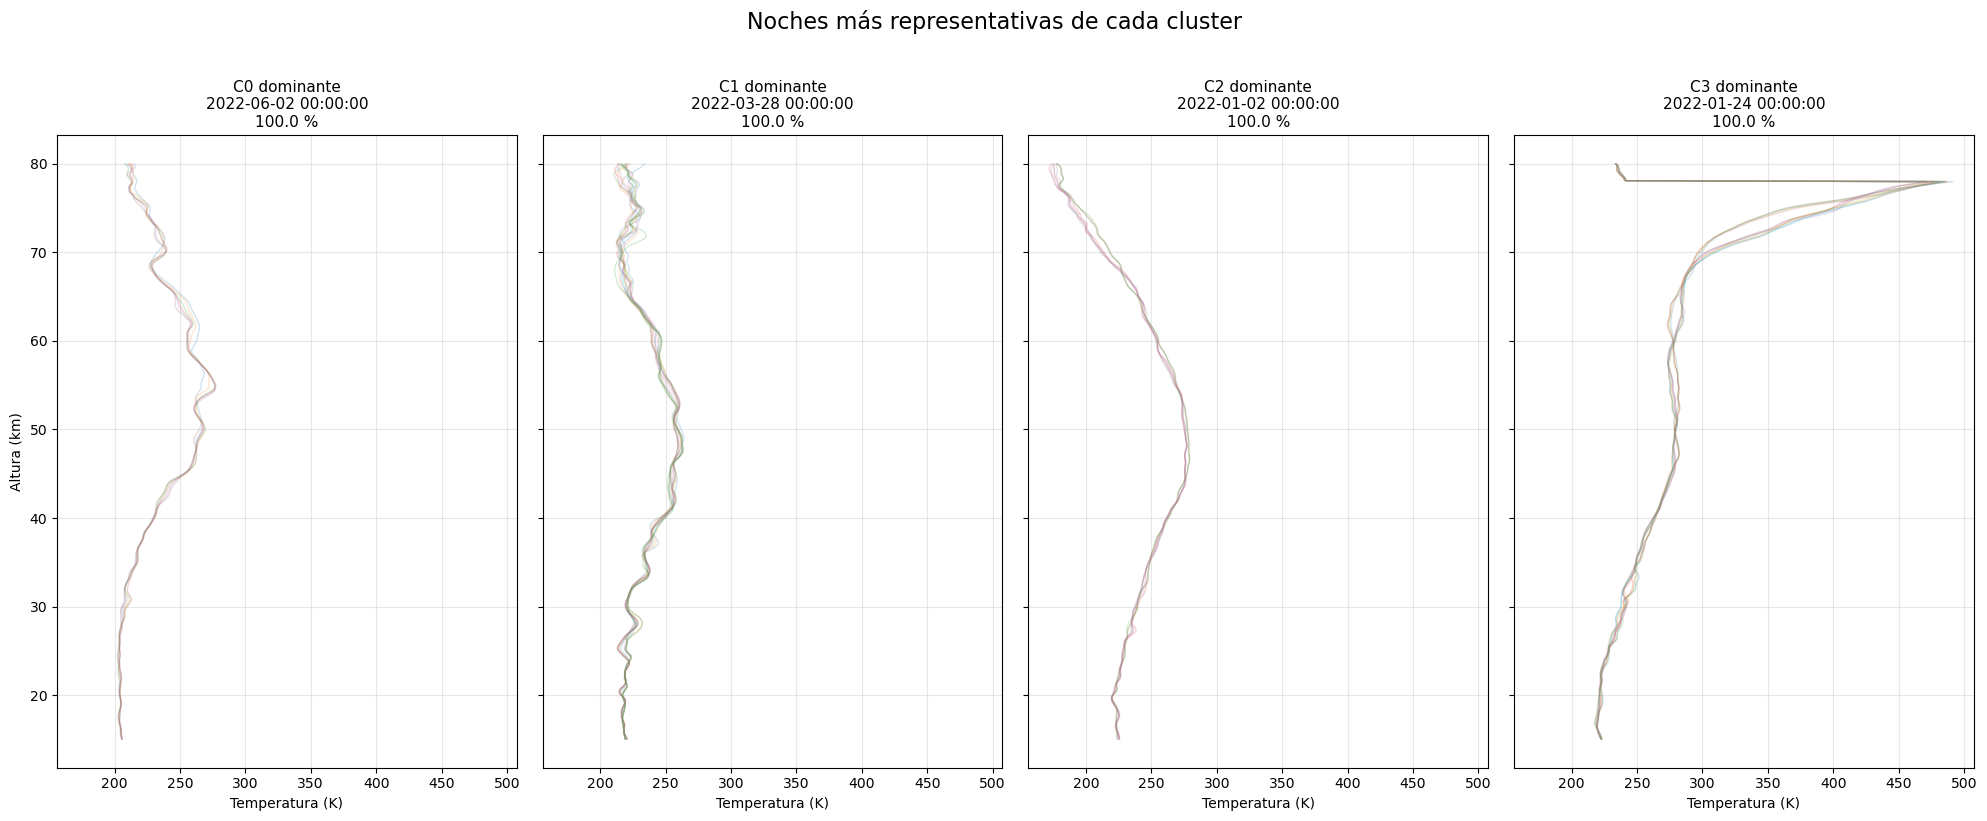

In [38]:
# Vamos a graficarlas

# ============================================================
# Grilla 1x4
# Noche más representativa de cada cluster
# ============================================================

fig, axes = plt.subplots(
    1, 4,
    figsize=(20, 8),
    sharex=True,
    sharey=True
)

for ax, cluster in zip(axes, ["C0", "C1", "C2", "C3"]):

    fecha = fechas_clusters[cluster]["fecha"]
    porcentaje = fechas_clusters[cluster]["porcentaje"]

    noche = df_C[
        df_C["fecha"] == fecha
    ].copy()

    noche = noche.sort_values("time")

    # --------------------------------------------------------
    # Graficar perfiles
    # --------------------------------------------------------

    for c in sorted(noche["cluster_4"].unique()):

        datos_cluster = noche[
            noche["cluster_4"] == c
        ]

        for _, fila in datos_cluster.iterrows():

            perfil = fila[X_temp_C.columns]

            ax.plot(
                perfil,
                alturas_km,
                alpha=0.20,
                linewidth=1
            )

    # --------------------------------------------------------
    # Título
    # --------------------------------------------------------

    ax.set_title(
        f"{cluster} dominante\n"
        f"{fecha}\n"
        f"{100*porcentaje:.1f} %",
        fontsize=11
    )

    ax.set_xlabel("Temperatura (K)")

    ax.grid(alpha=0.3)

# ------------------------------------------------------------
# Etiqueta Y sólo a la izquierda
# ------------------------------------------------------------

axes[0].set_ylabel("Altura (km)")

# ------------------------------------------------------------
# Título general
# ------------------------------------------------------------

plt.suptitle(
    "Noches más representativas de cada cluster",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.show()

In [39]:
# Vamos a ver las 10 noche más representativas de C3

top_10_C3 = (
    distribucion_nocturna
    .sort_values("C3", ascending=False)
    .head(10)
)

top_10_C3[["C0", "C1", "C2", "C3", "cluster_dominante", "max_pct"]]


,C0,C1,C2,C3,cluster_dominante,max_pct
fecha,,,,,,
2024-05-06,0.0,0.0,0.0,1.0,C3,1.0
2022-06-13,0.0,0.0,0.0,1.0,C3,1.0
2022-07-11,0.0,0.0,0.0,1.0,C3,1.0
2022-07-09,0.0,0.0,0.0,1.0,C3,1.0
2022-07-08,0.0,0.0,0.0,1.0,C3,1.0
2024-04-22,0.0,0.0,0.0,1.0,C3,1.0
2024-04-21,0.0,0.0,0.0,1.0,C3,1.0
2023-04-18,0.0,0.0,0.0,1.0,C3,1.0
2022-06-21,0.0,0.0,0.0,1.0,C3,1.0


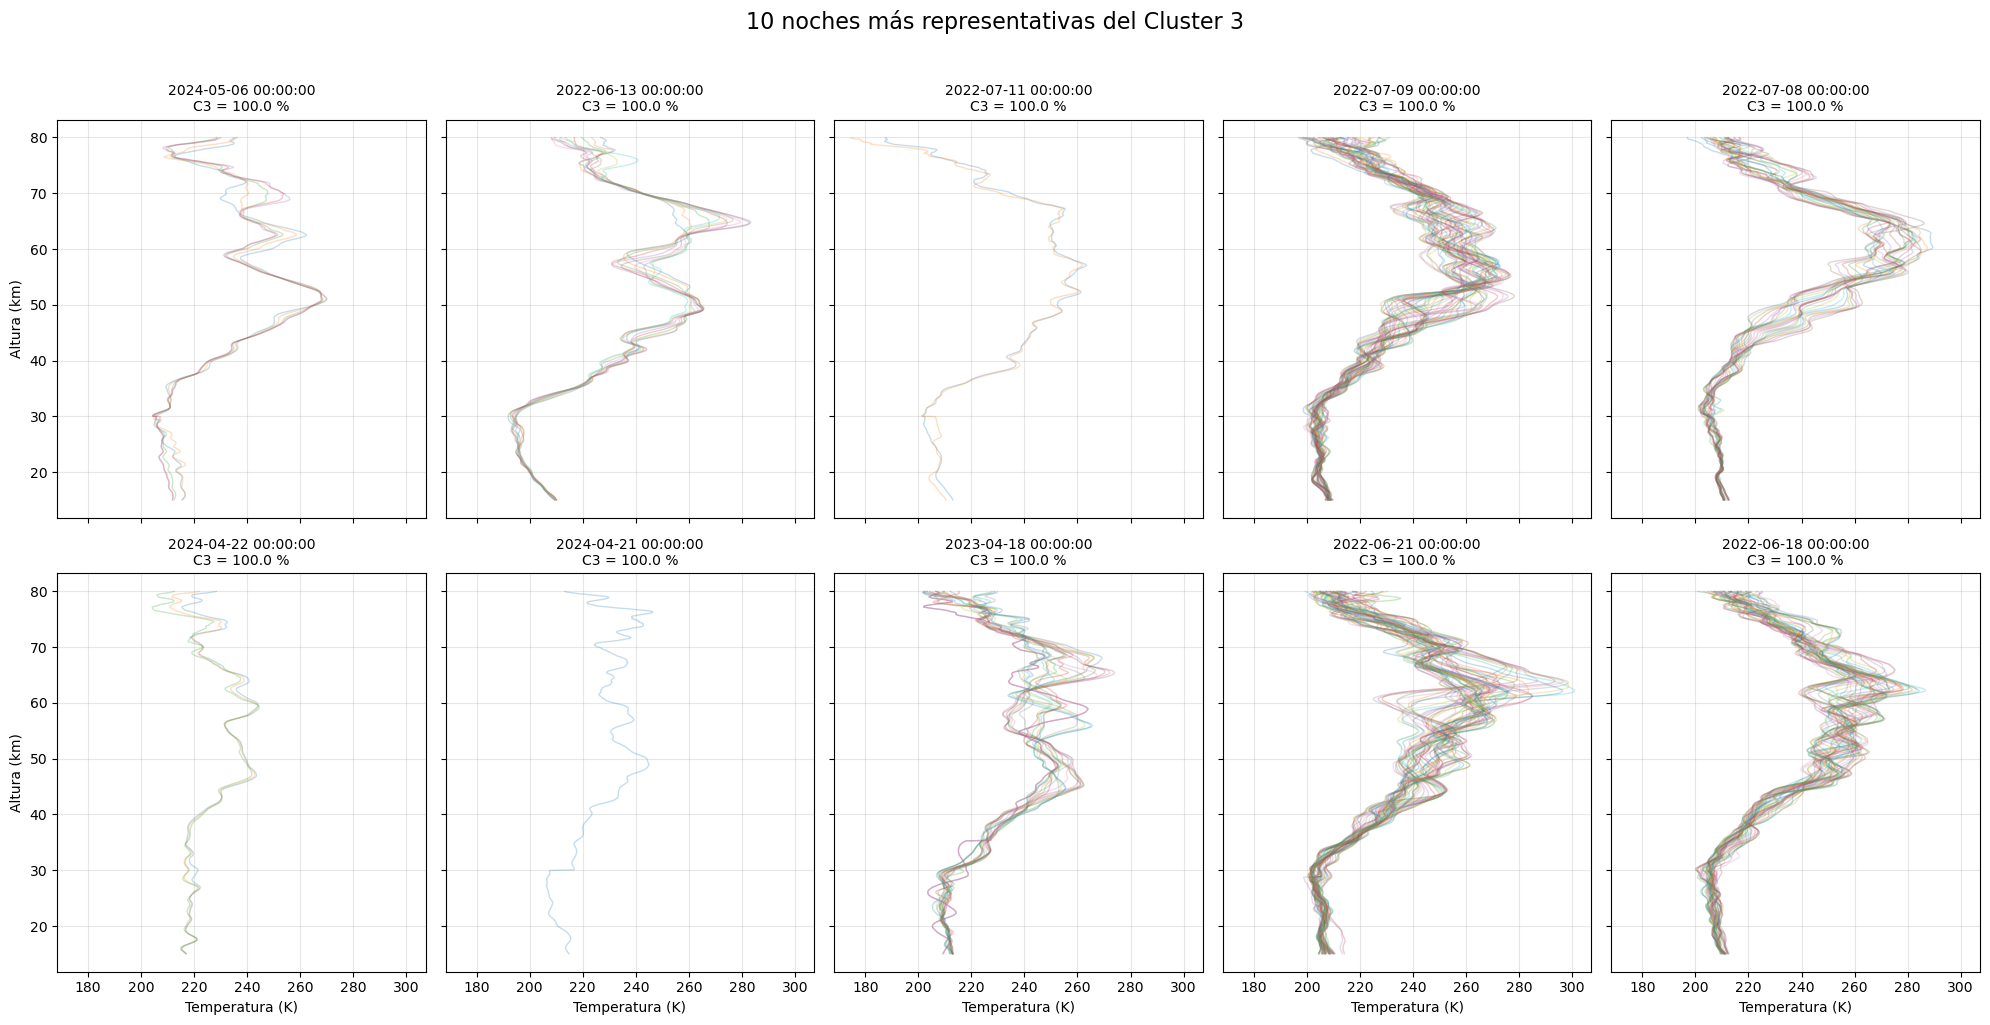

In [40]:
# ============================================================
# Grilla 2x5 - Noches más representativas de C3
# ============================================================

fig, axes = plt.subplots(
    2, 5,
    figsize=(20, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, fecha in zip(axes, top_10_C3.index):

    noche = df_C[df_C["fecha"] == fecha].copy()
    noche = noche.sort_values("time")

    porcentaje_C3 = top_10_C3.loc[fecha, "C3"]

    for _, fila in noche.iterrows():

        perfil = fila[X_temp_C.columns]

        ax.plot(
            perfil,
            alturas_km,
            alpha=0.25,
            linewidth=1
        )

    ax.set_title(
        f"{fecha}\nC3 = {100*porcentaje_C3:.1f} %",
        fontsize=10
    )

    ax.grid(alpha=0.3)

# ------------------------------------------------------------
# Etiquetas
# ------------------------------------------------------------

for ax in axes[::5]:
    ax.set_ylabel("Altura (km)")

for ax in axes[-5:]:
    ax.set_xlabel("Temperatura (K)")

# ------------------------------------------------------------
# Título general
# ------------------------------------------------------------

plt.suptitle(
    "10 noches más representativas del Cluster 3",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.show()

In [41]:
df_C.head()

,archivo,fecha,time,15068,15168,15268,15368,15468,15568,15668,...,79868,79968,cluster_4,cluster_5,cluster_2,cluster_3,cluster_6,cluster_7,mes,estacion
0,20220102-0204_T60Z900,2022-01-02,10110000,224.12709,224.06079,224.03088,224.00032,224.00107,223.97531,223.91777,...,178.84262,178.01134,2,0,0,1,2,5,1,Verano
1,20220102-0204_T60Z900,2022-01-02,11010000,224.15086,224.08093,224.04492,224.00494,223.99844,223.96309,223.89388,...,178.84262,178.01134,2,0,0,1,2,5,1,Verano
2,20220102-0204_T60Z900,2022-01-02,11910000,223.87470,223.81165,223.79224,223.75688,223.75171,223.71470,223.63731,...,178.46750,177.62988,2,0,0,1,2,5,1,Verano
3,20220102-0204_T60Z900,2022-01-02,14610000,225.60756,225.46303,225.28813,225.04552,224.78656,224.51508,224.26501,...,172.93466,173.25317,2,0,0,1,2,5,1,Verano
4,20220102-0204_T60Z900,2022-01-02,15510000,225.51476,225.39750,225.27725,225.07066,224.84776,224.61030,224.36234,...,174.40381,174.74709,2,0,0,1,2,5,1,Verano


In [42]:
distribucion_nocturna.head()

,C0,C1,C2,C3,cluster_dominante,max_pct,entropia
fecha,,,,,,,
2022-01-02,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2022-01-03,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2022-01-04,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2022-01-06,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11
2022-01-08,0.0,0.0,1.0,0.0,C2,1.0,8.589311e-11


In [43]:
# Vamos a guardar los archivos

df_C.to_csv("dataset_C_clusterizado_k2_k7_mes_estacion.csv", index=False)

print("Archivo guardado:")
print("dataset_C_clusterizado_k2_k7_mes_estacion.csv")

distribucion_nocturna.to_csv("resumen_nocturno_clusters.csv")

print("Archivo guardado:")
print("resumen_nocturno_clusters.csv")


Archivo guardado:
dataset_C_clusterizado_k2_k7_mes_estacion.csv
Archivo guardado:
resumen_nocturno_clusters.csv


In [45]:
# Exportación del modelo K-Means K=4

import joblib
from pathlib import Path

carpeta_modelo = Path("modelo_exportado")
carpeta_modelo.mkdir(exist_ok=True)

alturas_modelo = X_temp_C.columns.tolist()

artefacto_clustering = {
    "kmeans": kmeans_4,
    "alturas_modelo": alturas_modelo,
    "metadata": {
        "modelo": "KMeans",
        "k": 4,
        "dataset_entrenamiento": "Dataset C",
        "n_perfiles_entrenamiento": X_temp_C.shape[0],
        "n_alturas": X_temp_C.shape[1],
        "rango_alturas_m": [
            float(alturas_modelo[0]),
            float(alturas_modelo[-1])
        ],
        "usa_scaler": False
    }
}

joblib.dump(
    artefacto_clustering,
    carpeta_modelo / "clustering_kmeans_k4.pkl"
)

archivo_clustering = carpeta_modelo / "clustering_kmeans_k4.pkl"

print("Archivo guardado:", archivo_clustering.exists())
print("Ruta:", archivo_clustering.resolve())
print("Cantidad de clusters:", kmeans_4.n_clusters)
print("Cantidad de perfiles:", X_temp_C.shape[0])
print("Cantidad de alturas:", len(alturas_modelo))
print("Primera altura:", alturas_modelo[0])
print("Última altura:", alturas_modelo[-1])

Archivo guardado: True
Ruta: C:\Users\orlan\Documents\Aprendizaje Automatico\TP\modelo_exportado\clustering_kmeans_k4.pkl
Cantidad de clusters: 4
Cantidad de perfiles: 11041
Cantidad de alturas: 650
Primera altura: 15068
Última altura: 79968
